In [1]:
import torch
import torchvision
from lexplainet.implicit.rules import *

device = "cuda" if torch.cuda.is_available() else "cpu"

def model_loader(model_name, device):
    if model_name == "resnet18":
        model = torchvision.models.resnet18(pretrained=True)
    elif model_name == "resnet34":
        model = torchvision.models.resnet34(pretrained=True)
    elif model_name == "resnet50":
        model = torchvision.models.resnet50(pretrained=True)
    elif model_name == "vgg16":
        model = torchvision.models.vgg16(pretrained=True)
    elif model_name == "vgg16_bn":
        model = torchvision.models.vgg16_bn(pretrained=True)
    elif model_name == "efficientnet_b0":
        model = torchvision.models.efficientnet_b0(pretrained=True)
    elif model_name == "efficientnet_b1":
        model = torchvision.models.efficientnet_b1(pretrained=True)
    else:
        raise ValueError("Unsupported model name")
    
    model = model.to(device)
    model.device = device
    model.eval()
    return model

model = model_loader("resnet18", device)

/home/erfan/venvs/llm_pruning/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/erfan/venvs/llm_pruning/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

from imagenet import IMAGENET_CLASS_NAMES
from imagenet.utils import inference_transform
from lexplainet.heatmap import show_image, load_image, plot_heatmap

Image Tensor Shape: torch.Size([1, 3, 224, 224])


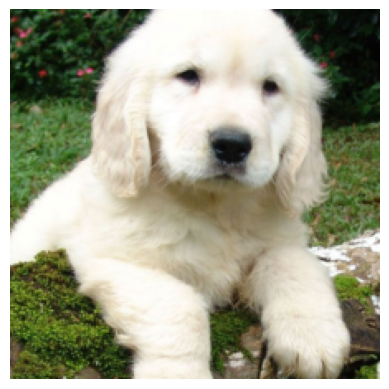

<Figure size 640x480 with 0 Axes>

In [3]:
image_tensor = load_image('./dog_1.png', transform=inference_transform, device=device)
show_image(image_tensor, transform=inference_transform)

In [4]:
from model_utils.inference import forward_pass
from model_utils.autograd import make_gradient_output, compute_relevance

In [22]:
from lexplainet.implicit.model_specific_patches import canonize_resnet
canonize_resnet(model)

Canonize linear and BatchNorm layers: features.0 and features.1
Canonize linear and BatchNorm layers: features.3 and features.4
Canonize linear and BatchNorm layers: features.7 and features.8
Canonize linear and BatchNorm layers: features.10 and features.11
Canonize linear and BatchNorm layers: features.14 and features.15
Canonize linear and BatchNorm layers: features.17 and features.18
Canonize linear and BatchNorm layers: features.20 and features.21
Canonize linear and BatchNorm layers: features.24 and features.25
Canonize linear and BatchNorm layers: features.27 and features.28
Canonize linear and BatchNorm layers: features.30 and features.31
Canonize linear and BatchNorm layers: features.34 and features.35
Canonize linear and BatchNorm layers: features.37 and features.38
Canonize linear and BatchNorm layers: features.40 and features.41


In [5]:
from lexplainet.implicit.composite_core import patch_composite, undo_patch_all
from lexplainet.implicit.rules import gamma_rule, identity_rule, epsilon_rule, lifted_gamma_rule

undo_patch_all(model)
composite = {
            torch.nn.Conv2d: (gamma_rule, {'gamma': 1000.}), 
            # torch.nn.Conv2d: (lifted_gamma_rule, {'gamma': 1000.}),
            torch.nn.ReLU: (identity_rule, {}),
            torch.nn.BatchNorm2d: (identity_rule, {}),
            torch.nn.Linear: (epsilon_rule, {})
}

patch_composite(model, composite)

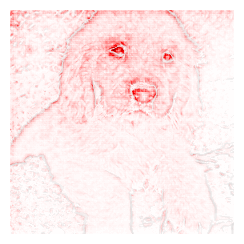

In [7]:
relevance, output = compute_relevance(model,
              image_tensor,
              targeted=True,
              init_relevance=1,
              normalize=True)
plot_heatmap(relevance, image=image_tensor, save=False, edge_overlay=True)

Image Tensor Shape: torch.Size([1, 3, 224, 224])


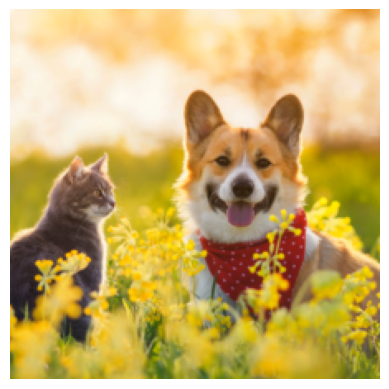

<Figure size 640x480 with 0 Axes>

In [10]:
image_tensor = load_image('./dog_2.png', transform=inference_transform, device=device)
show_image(image_tensor, transform=inference_transform)

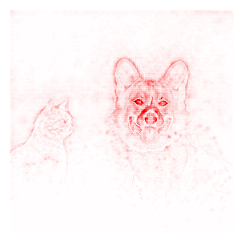

In [11]:
image_tensor.requires_grad = True

output = forward_pass(model, image_tensor, gradient_required=True)
predicted_class = output.argmax(dim=1).item()

gradient_output = make_gradient_output(output, predicted_class)
output.backward(gradient_output)

relevance = image_tensor.grad.detach().cpu() * image_tensor.detach().cpu()
lrp_normalized_relevance = (relevance / torch.max(torch.abs(relevance))).sum(dim=1)
plot_heatmap(lrp_normalized_relevance, save=True, save_path="resnet18_lrp_heatmap_dog_1.png")

In [12]:
# here we also do it for EfficientNet, which has the SqueezeExcitation module, and we use a custom rule for it
model = model_loader("efficientnet_b1", device)

/home/erfan/venvs/llm_pruning/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/erfan/venvs/llm_pruning/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B1_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [17]:
from torchvision.ops import SqueezeExcitation

from lexplainet.implicit.model_specific_patches import canonize_efficientnet, se_block_gate_forward, se_uniform_product_forward
canonize_efficientnet(model)
from lexplainet.implicit.composite_core import patch_composite, undo_patch_all
from lexplainet.implicit.rules import gamma_rule, identity_rule, epsilon_rule, lifted_gamma_rule, zplus_rule

undo_patch_all(model)
composite = {
            torch.nn.Conv2d: (zplus_rule, {}),
            torch.nn.ReLU: (identity_rule, {}),
            torch.nn.Sigmoid: (identity_rule, {}),
            torch.nn.SiLU: (identity_rule, {}),
            torch.nn.BatchNorm2d: (identity_rule, {}),
            torch.nn.Dropout: (identity_rule, {}),
            torch.nn.Linear: (epsilon_rule, {}),
            SqueezeExcitation: (se_block_gate_forward, {})
}

patch_composite(model, composite)

Canonize linear and BatchNorm layers: features.0.0 and features.0.1
Canonize linear and BatchNorm layers: features.1.0.block.0.0 and features.1.0.block.0.1
Canonize linear and BatchNorm layers: features.1.0.block.2.0 and features.1.0.block.2.1
Canonize linear and BatchNorm layers: features.1.1.block.0.0 and features.1.1.block.0.1
Canonize linear and BatchNorm layers: features.1.1.block.2.0 and features.1.1.block.2.1
Canonize linear and BatchNorm layers: features.2.0.block.0.0 and features.2.0.block.0.1
Canonize linear and BatchNorm layers: features.2.0.block.1.0 and features.2.0.block.1.1
Canonize linear and BatchNorm layers: features.2.0.block.3.0 and features.2.0.block.3.1
Canonize linear and BatchNorm layers: features.2.1.block.0.0 and features.2.1.block.0.1
Canonize linear and BatchNorm layers: features.2.1.block.1.0 and features.2.1.block.1.1
Canonize linear and BatchNorm layers: features.2.1.block.3.0 and features.2.1.block.3.1
Canonize linear and BatchNorm layers: features.2.2.b

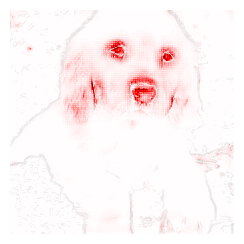

In [18]:
image_tensor = load_image('./dog_1.png', transform=inference_transform, device=device)
relevance, output = compute_relevance(model,
              image_tensor,
              targeted=True,
              init_relevance=1,
              normalize=True)
plot_heatmap(relevance, image=image_tensor, save=False, edge_overlay=True)

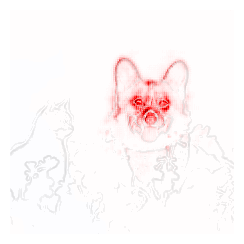

In [19]:
image_tensor = load_image('./dog_2.png', transform=inference_transform, device=device)
relevance, output = compute_relevance(model,
              image_tensor,
              targeted=True,
              init_relevance=1,
              normalize=True)
plot_heatmap(relevance, image=image_tensor, save=False, edge_overlay=True)